   MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  \
0      8.0     24.3       0.0          3.4       6.3          NW   
1     14.0     26.9       3.6          4.4       9.7         ENE   
2     13.7     23.4       3.6          5.8       3.3          NW   
3     13.3     15.5      39.8          7.2       9.1          NW   
4      7.6     16.1       2.8          5.6      10.6         SSE   

   WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0           30.0         SW         NW           6.0  ...           29   
1           39.0          E          W           4.0  ...           36   
2           85.0          N        NNE           6.0  ...           69   
3           54.0        WNW          W          30.0  ...           56   
4           50.0        SSE        ESE          20.0  ...           49   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1019.7       1015.0         7         7     14.4     23.6 

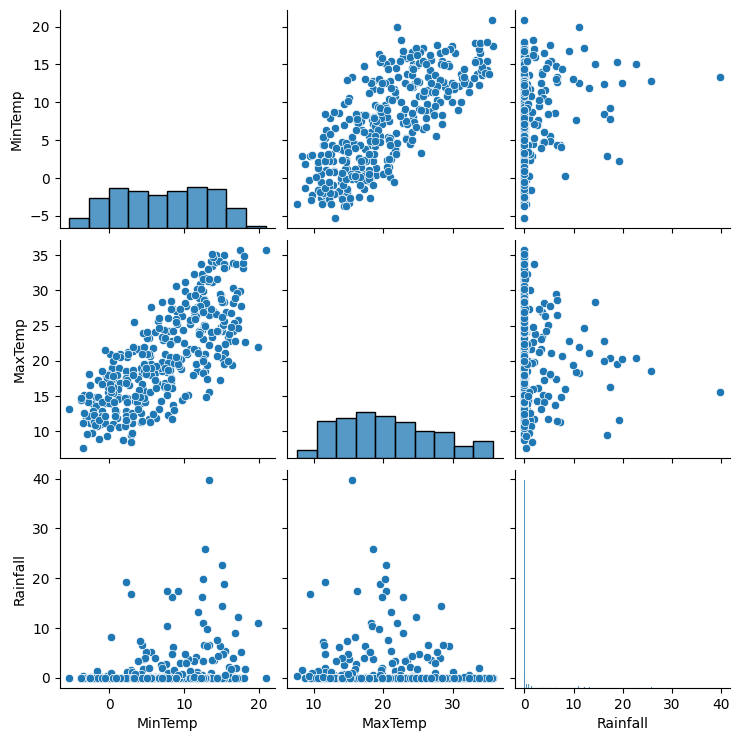

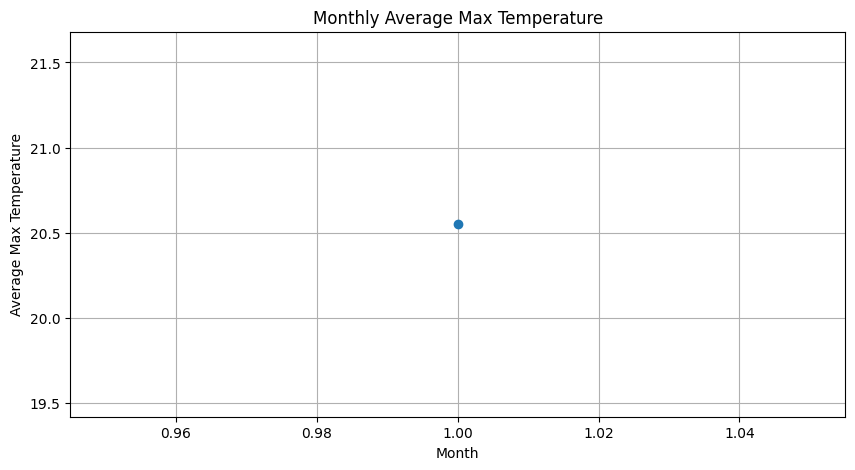

Mean Squared Error for Rainfall Prediction: 37.0768456005826
Highest rainfall month: 1, Lowest rainfall month: 1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Step 1: Load the Data
# Reads the weather dataset CSV file
df = pd.read_csv('/content/weather.csv')

# Step 2: Data Exploration

# Displays first 5 rows of dataset
print(df.head())

# Displays dataset information such as columns, datatypes, and missing values
print(df.info())

# Displays statistical summary of numerical columns
print(df.describe())

# Step 3: Data Visualization

# Creates pairplot to visualize relationship between:
# MinTemp, MaxTemp, and Rainfall
sns.pairplot(df[['MinTemp', 'MaxTemp', 'Rainfall']])

# Displays the graph
plt.show()

# Step 4: Feature Engineering (if needed)

# Step 5: Data Analysis (analyze each term)

# Converts MaxTemp column into datetime format
df['Date'] = pd.to_datetime(df['MaxTemp'])

# Extracts month values from Date column
df['Month'] = df['Date'].dt.month

# Calculates average maximum temperature for each month
monthly_avg_max_temp = df.groupby('Month')['MaxTemp'].mean()

# Step 6: Data Visualization (Part 2)

# Creates figure size
plt.figure(figsize=(10, 5))

# Creates line plot for monthly average maximum temperature
plt.plot(
    monthly_avg_max_temp.index,
    monthly_avg_max_temp.values,
    marker='o'
)

# Labels x-axis
plt.xlabel('Month')

# Labels y-axis
plt.ylabel('Average Max Temperature')

# Adds graph title
plt.title('Monthly Average Max Temperature')

# Adds grid to graph
plt.grid(True)

# Displays graph
plt.show()

# Step 7: Advanced Analysis (e.g., predict Rainfall)

# Selects features for prediction
X = df[['MinTemp', 'MaxTemp']]

# Selects target variable
y = df['Rainfall']

# Splits dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Creates Linear Regression model
model = LinearRegression()

# Trains the model using training data
model.fit(X_train, y_train)

# Predicts rainfall values using testing data
y_pred = model.predict(X_test)

# Calculates Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Displays Mean Squared Error
print(f'Mean Squared Error for Rainfall Prediction: {mse}')

# Step 8: Conclusions and Insights (analyze each term)

# Identifies month with highest average maximum temperature
highest_rainfall_month = monthly_avg_max_temp.idxmax()

# Identifies month with lowest average maximum temperature
lowest_rainfall_month = monthly_avg_max_temp.idxmin()

# Displays results
print(
    f'Highest rainfall month: {highest_rainfall_month}, '
    f'Lowest rainfall month: {lowest_rainfall_month}'
)